### Spatio-Temporal Crime Prediction (for Violent Crime)
**Aim:** Predict the probability ($P$) that a crime will occur in a specific tile at a specific time. To direct patrol units (beats) to perform "proactive presence" in these specific tiles during their shift.

### Setup


In [90]:
# Install required packages (run once if needed)
!pip install geopandas h3 xgboost scikit-learn pandas numpy matplotlib seaborn joblib contextily catboost lightgbm --quiet

In [91]:
# =============================================================================
# IMPORTS
# =============================================================================
# Data manipulation
import pandas as pd
import numpy as np
import geopandas as gpd
import h3
from shapely.geometry import Polygon

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx # Added contextily import

# Math utilities
from math import radians  # For converting degrees to radians (used in Haversine formula)

# File I/O
import json
import joblib  # For saving/loading sklearn models
import os

# Machine Learning
import xgboost as xgb  # Gradient boosting library
import lightgbm as lgb  # Gradient boosting library (fast, memory-efficient)
from sklearn.ensemble import RandomForestClassifier  # Bagging ensemble method
from catboost import CatBoostClassifier  # Gradient boosting library with native categorical support
from lightgbm import LGBMClassifier  # LightGBM classifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder  # For categorical encoding in pipelines
from sklearn.compose import ColumnTransformer  # Apply different transforms to different columns
from sklearn.pipeline import Pipeline  # Chain preprocessing + model together
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


---
### Step 1: Load Data

We load data from two parquet files (after DatasetDownload to local drive):
- **ChicagoCrimes(20152025).parquet**: Reported crime incidents in Chicago from 2015 to 2025 (crime types, locations, dates and arrest status)
- **ChicagoCommunityArea.parquet**: Geographic and administrative information of Chicago's 77 official community areas 
- **Chicago Police Beats Boundary (API)**: Current police beat boundaries in Chicago

In [92]:
from pathlib import Path
from shapely.geometry import shape

print("="*60)
print("STEP 1: LOAD DATA")
print("="*60)

# Resolve path relative to this notebook location
notebook_dir = Path.cwd()
base_dir = notebook_dir.parent.parent  # IT5006Group
project_data_dir = base_dir / "ProjectData"

community_path = project_data_dir / "chicagocommunityarea.parquet"
crimes_path = project_data_dir / "chicagocrimes(20152025).parquet"

if not community_path.exists() or not crimes_path.exists():
    raise FileNotFoundError(
        "Could not find one or both parquet files in ProjectData.\n"
        f"Expected:\n- {community_path}\n- {crimes_path}"
    )

print(f"\nLoading data from:\n  {community_path}\n  {crimes_path}")

# Load Chicago community area lookup table
community_df = pd.read_parquet(community_path)
print(f"   {community_path.name}: {len(community_df):,} rows")

# Load Chicago crimes main dataset
crimes_df = pd.read_parquet(crimes_path)
print(f"   {crimes_path.name}: {len(crimes_df):,} rows")

# Load Chicago Police Beats boundary dataset (SODA2 API endpoint from portal)
beats_url = "https://data.cityofchicago.org/resource/n9it-hstw.json?$limit=5000"
beats_df = pd.read_json(beats_url)

if "the_geom" in beats_df.columns:
    beats_gdf = gpd.GeoDataFrame(
        beats_df.drop(columns=["the_geom"]).copy(),
        geometry=beats_df["the_geom"].apply(lambda geom: shape(geom) if isinstance(geom, dict) else None),
        crs="EPSG:4326"
    )
else:
    beats_gdf = gpd.GeoDataFrame(beats_df.copy(), geometry=None)

print(f"   Chicago Police Beats (API): {len(beats_df):,} rows")
if "geometry" in beats_gdf.columns:
    print(f"   Beats with valid geometry: {beats_gdf.geometry.notna().sum():,}")

print("\nDataset Statistics:")
print(f"   Total crime records: {len(crimes_df):,}")

# # Calculate arres rate and domesticity - important for understanding class imbalanceumns are available
printed_any_rate = False

if "Arrest" in crimes_df.columns:
    arrest_rate = crimes_df["Arrest"].astype(bool).mean() * 100
    print(f"   Arrest=True: {crimes_df['Arrest'].astype(bool).sum():,} ({arrest_rate:.2f}%)")
    printed_any_rate = True

if "Domestic" in crimes_df.columns:
    domestic_rate = crimes_df["Domestic"].astype(bool).mean() * 100
    print(f"   Domestic=True: {crimes_df['Domestic'].astype(bool).sum():,} ({domestic_rate:.2f}%)")
    printed_any_rate = True

if not printed_any_rate:
    print("   No 'Arrest' or 'Domestic' column found; skipped label summary.")

STEP 1: LOAD DATA

Loading data from:
  c:\Users\tpi_5\Documents\Masters\4. IT5006 Data Analytics\IT5006Group\ProjectData\chicagocommunityarea.parquet
  c:\Users\tpi_5\Documents\Masters\4. IT5006 Data Analytics\IT5006Group\ProjectData\chicagocrimes(20152025).parquet
   chicagocommunityarea.parquet: 77 rows
   chicagocrimes(20152025).parquet: 2,755,021 rows
   Chicago Police Beats (API): 277 rows
   Beats with valid geometry: 277

Dataset Statistics:
   Total crime records: 2,755,021
   Arrest=True: 480,385 (17.44%)
   Domestic=True: 532,290 (19.32%)


In [93]:
# Preview the data
print("\n Sample crime records:")
crimes_df.head(3)


 Sample crime records:


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13711023,JJ103490,01/01/2015 12:00:00 AM,088XX S BISHOP ST,1261,DECEPTIVE PRACTICE,UNAUTHORIZED VIDEOTAPING,RESIDENCE,False,True,...,21.0,71.0,11,NaN,NaN,2015,01/05/2025 03:42:25 PM,NaN,NaN,None
1,13368845,JH152261,01/01/2015 12:00:00 AM,001XX N STATE ST,1150,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,DEPARTMENT STORE,False,False,...,34.0,32.0,11,NaN,NaN,2015,02/15/2024 03:40:52 PM,NaN,NaN,None
2,13448318,JH247450,01/01/2015 12:00:00 AM,010XX N LECLAIRE AVE,1754,OFFENSE INVOLVING CHILDREN,AGGRAVATED SEXUAL ASSAULT OF CHILD BY FAMILY M...,RESIDENCE,False,True,...,37.0,25.0,02,NaN,NaN,2015,05/03/2024 03:41:27 PM,NaN,NaN,None


In [94]:
# Preview the data
print("\n Sample community area data:")
community_df.head(3)


 Sample community area data:


,the_geom,AREA_NUMBE,COMMUNITY,AREA_NUM_1,SHAPE_AREA,SHAPE_LEN
0,MULTIPOLYGON (((-87.65455590025104 41.99816614...,1,ROGERS PARK,1,"51.259.902,4506","34.052,3975757"
1,MULTIPOLYGON (((-87.6846530946559 42.019484772...,2,WEST RIDGE,2,"98.429.094,8621","43.020,6894583"
2,MULTIPOLYGON (((-87.64102430213292 41.95480280...,3,UPTOWN,3,"65.095.642,7289","46.972,7945549"


In [95]:
# Preview the data
print("\n Sample beat data:")
beats_df.head(3)


 Sample beat data:


,the_geom,district,sector,beat,beat_num
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",17,1,1,1713
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",31,0,0,3100
2,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",16,5,5,1651


---
### Step 2: Preprocess data (Filter, Clean, Grid)

- **Violent Crime** - targeting predictable violent crime, focused on primary type within top 10 offences: BATTERY, ASSAULT and ROBBERY
- **Last 3 years (Train) and Last 1 year (Test)** - avoiding 2020 and 2021 due to Covid-19, using 2022 to 2024 for training and 2025 for testing
- **Missing Data** - drop records with missing latitude, longitude, date and out of Chicago boundaries
- **Grid** - assign every crime incident to a tile ID and create master grid of (tile x date)

In [96]:
# Define violent crime labels
# violent_crimes = [
#     'HOMICIDE', 'BATTERY', 'ASSAULT', 'ROBBERY',
#     'CRIMINAL SEXUAL ASSAULT', 'CRIM SEXUAL ASSAULT',
#     'KIDNAPPING', 'HUMAN TRAFFICKING', 'STALKING', 'INTIMIDATION'
#  ]

violent_crimes = [
    'BATTERY', 'ASSAULT', 'ROBBERY']

# Create binary violent flag
crimes_df['is_violent'] = crimes_df['Primary Type'].isin(violent_crimes).astype(int)

# Keep only violent crime records
rows_before = len(crimes_df)
crimes_df = crimes_df[crimes_df['is_violent'] == 1].copy()
rows_after = len(crimes_df)

print("Filtered to violent crimes only")
print(f"Rows before: {rows_before:,}")
print(f"Rows after : {rows_after:,}")
print(f"Removed    : {rows_before - rows_after:,}")
print("\nPrimary Type counts (violent only):")
print(crimes_df['Primary Type'].value_counts())

Filtered to violent crimes only
Rows before: 2,755,021
Rows after : 828,741
Removed    : 1,926,280

Primary Type counts (violent only):
Primary Type
BATTERY    503679
ASSAULT    223180
ROBBERY    101882
Name: count, dtype: int64


In [97]:
# Filter to records from years 2022, 2023, 2024 and 2025
# Assumes crimes_df is already loaded

rows_before = len(crimes_df)

target_years = [2022, 2023, 2024, 2025]
crimes_df = crimes_df[crimes_df["Year"].isin(target_years)].copy()
rows_after = len(crimes_df)

print("Filtered crimes_df successfully")
print(f"Rows before: {rows_before:,}")
print(f"Rows after : {rows_after:,}")
print(f"Removed    : {rows_before - rows_after:,}")
print(f"Kept years : {target_years}")

Filtered crimes_df successfully
Rows before: 828,741
Rows after : 297,247
Removed    : 531,494
Kept years : [2022, 2023, 2024, 2025]


In [98]:
# Drop records with missing Latitude, Longitude, or Date,
# then keep only rows within Chicago city bounds
# Assumes crimes_df is already loaded and filtered

# Ensure Date is datetime so invalid dates become NaT
crimes_df["Date"] = pd.to_datetime(crimes_df["Date"], errors="coerce")

rows_before = len(crimes_df)

# 1) Drop missing geo/date values
crimes_df = crimes_df.dropna(subset=["Latitude", "Longitude", "Date"]).copy()
rows_after_dropna = len(crimes_df)

# 2) Keep only coordinates within Chicago limits
chicago_mask = (
    (crimes_df["Latitude"] > 41.6) & (crimes_df["Latitude"] < 42.1) &
    (crimes_df["Longitude"] > -88.0) & (crimes_df["Longitude"] < -87.5)
)
crimes_df = crimes_df[chicago_mask].copy()
rows_after_bounds = len(crimes_df)

print("Cleaned crimes_df successfully")
print(f"Rows before cleaning        : {rows_before:,}")
print(f"After dropping missing vals : {rows_after_dropna:,}")
print(f"After Chicago bounds filter : {rows_after_bounds:,}")
print(f"Total removed              : {rows_before - rows_after_bounds:,}")

Cleaned crimes_df successfully
Rows before cleaning        : 297,247
After dropping missing vals : 296,425
After Chicago bounds filter : 296,424
Total removed              : 823


In [99]:
# Build H3 features from the current crimes_df
# Assumes crimes_df already contains cleaned Latitude, Longitude, and Date

RESOLUTION = 8  # Higher number = smaller hexagons e.g. 8 is ~0.7km^2 area

# Assign H3 cell id to each record
crimes_df["h3_address"] = crimes_df.apply(
    lambda row: h3.latlng_to_cell(row["Latitude"], row["Longitude"], RESOLUTION),
    axis=1
)

# Aggregate crimes per tile per day (this becomes model input)
# Grouping by Tile and Date (for daily probability)
df_h3 = crimes_df.copy()
df_h3["Date"] = df_h3["Date"].dt.date
tile_counts = (
    df_h3.groupby(["h3_address", "Date"]).size().reset_index(name="crime_count")
)

# Convert H3 cells to polygons for mapping
def h3_to_polygon(hex_id):
    boundary = h3.cell_to_boundary(hex_id)  # (lat, lng)
    return Polygon([(lng, lat) for lat, lng in boundary])

gdf_tiles = gpd.GeoDataFrame(
    tile_counts,
    geometry=tile_counts["h3_address"].apply(h3_to_polygon),
    crs="EPSG:4326"
)

print(f"H3 feature table created at resolution {RESOLUTION}")
print(f"Crime records used: {len(df_h3):,}")
print(f"Tile-day rows: {len(tile_counts):,}")
print(f"Unique tiles: {tile_counts['h3_address'].nunique():,}")
gdf_tiles.head()

H3 feature table created at resolution 8
Crime records used: 296,424
Tile-day rows: 230,050
Unique tiles: 857


,h3_address,Date,crime_count,geometry
0,8826641903fffff,2022-02-23,1,"POLYGON ((-87.54767 41.67405, -87.55369 41.672..."
1,8826641903fffff,2022-04-05,1,"POLYGON ((-87.54767 41.67405, -87.55369 41.672..."
2,8826641903fffff,2022-06-20,1,"POLYGON ((-87.54767 41.67405, -87.55369 41.672..."
3,8826641903fffff,2022-07-25,1,"POLYGON ((-87.54767 41.67405, -87.55369 41.672..."
4,8826641903fffff,2022-11-08,1,"POLYGON ((-87.54767 41.67405, -87.55369 41.672..."


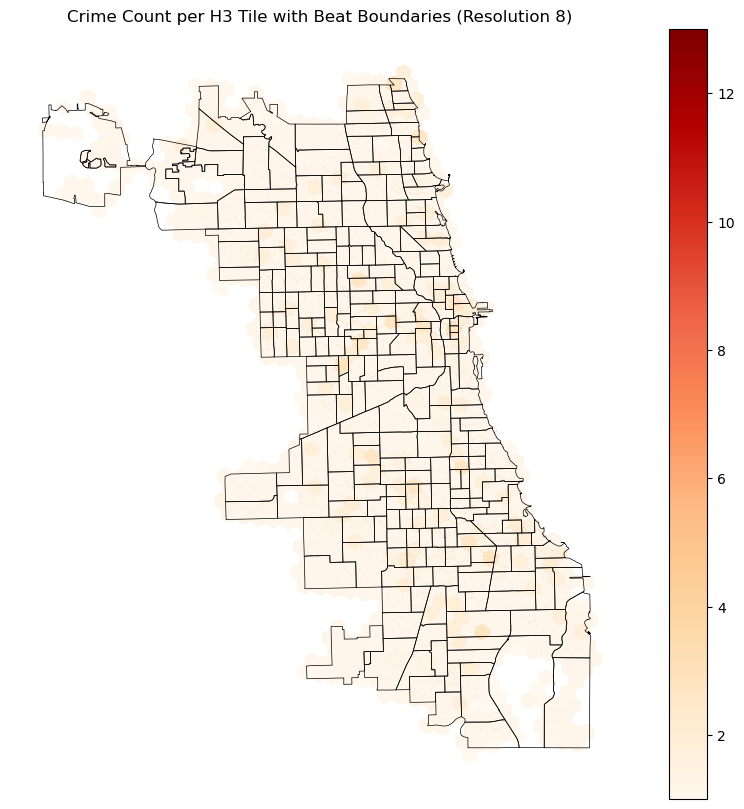

In [100]:
# Plot H3 crime intensity and overlay Chicago Beat boundaries
fig, ax = plt.subplots(figsize=(10, 10))

# Base layer: H3 tiles
gdf_tiles.to_crs("EPSG:4326").plot(
    column="crime_count",
    cmap="OrRd",
    legend=True,
    ax=ax,
    alpha=0.75
)

# Overlay: beat boundaries
beats_gdf.to_crs("EPSG:4326").boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

ax.set_title(f"Crime Count per H3 Tile with Beat Boundaries (Resolution {RESOLUTION})")
ax.set_axis_off()
plt.show()

In [101]:
# Create target variable by adding tile-shifts where crime did not happen (zero crime)
# Shift bins: morning/noon (06:00-14:00), afternoon/night (14:00-22:00), overnight (22:00-06:00)

# Ensure datetime
df_shift = crimes_df.copy()
df_shift["Date"] = pd.to_datetime(df_shift["Date"], errors="coerce")
df_shift = df_shift.dropna(subset=["Date", "h3_address"]).copy()

# 1) Assign each record to a shift and a shift_date (anchored to shift start date)
hour = df_shift["Date"].dt.hour
df_shift["shift"] = np.select(
    [hour.between(6, 13), hour.between(14, 21)],
    ["morning_noon", "afternoon_night"],
    default="overnight"
)

# For 00:00-05:59, the shift started the previous day at 22:00
df_shift["shift_date"] = df_shift["Date"].dt.floor("D")
df_shift.loc[hour < 6, "shift_date"] = df_shift.loc[hour < 6, "shift_date"] - pd.Timedelta(days=1)

# 2) Aggregate crimes per tile per shift
tile_shift_counts = (
    df_shift.groupby(["h3_address", "shift_date", "shift"]).size().reset_index(name="crime_count")
)

# 3) Create master grid: every (tile x date x shift)
all_h3_tiles = df_shift["h3_address"].unique()
all_shift_dates = pd.date_range(
    start=df_shift["shift_date"].min(),
    end=df_shift["shift_date"].max(),
    freq="D"
 )
shift_order = ["morning_noon", "afternoon_night", "overnight"]

index = pd.MultiIndex.from_product(
    [all_h3_tiles, all_shift_dates, shift_order],
    names=["h3_address", "shift_date", "shift"]
)
master_grid = pd.DataFrame(index=index).reset_index()

# 4) Merge actual counts onto master grid
final_df = pd.merge(
    master_grid,
    tile_shift_counts,
    on=["h3_address", "shift_date", "shift"],
    how="left"
 )

# 5) Fill no-crime shifts with 0 and create binary target
final_df["crime_count"] = final_df["crime_count"].fillna(0)
final_df["target"] = (final_df["crime_count"] > 0).astype(int)

# 6) Keep a Date column for downstream steps (shift start timestamp)
shift_start_hour = {"morning_noon": 6, "afternoon_night": 14, "overnight": 22}
final_df["Date"] = final_df["shift_date"] + pd.to_timedelta(final_df["shift"].map(shift_start_hour), unit="h")

# 7) Add hour derived from df_shift Date
hour_map = df_shift.groupby(["shift_date", "shift"])["Date"].apply(lambda x: int(x.dt.hour.mode().iloc[0])).to_dict()
final_df["hour"] = final_df.apply(
    lambda row: hour_map.get((row["shift_date"], row["shift"]), shift_start_hour[row["shift"]]),
    axis=1
)

In [102]:
# Preview the shift-level master grid
print("\nSample master grid (8-hour shifts):")
preview_cols = ["h3_address", "shift_date", "shift", "crime_count", "target", "Date", "hour"]
final_df[preview_cols].head(100)


Sample master grid (8-hour shifts):


,h3_address,shift_date,shift,crime_count,target,Date,hour
0,882664cccbfffff,2021-12-31,morning_noon,0.0,0,2021-12-31 06:00:00,6
1,882664cccbfffff,2021-12-31,afternoon_night,0.0,0,2021-12-31 14:00:00,14
2,882664cccbfffff,2021-12-31,overnight,1.0,1,2021-12-31 22:00:00,4
3,882664cccbfffff,2022-01-01,morning_noon,0.0,0,2022-01-01 06:00:00,7
4,882664cccbfffff,2022-01-01,afternoon_night,0.0,0,2022-01-01 14:00:00,21
...,...,...,...,...,...,...,...
95,882664cccbfffff,2022-01-31,overnight,0.0,0,2022-01-31 22:00:00,0
96,882664cccbfffff,2022-02-01,morning_noon,0.0,0,2022-02-01 06:00:00,12
97,882664cccbfffff,2022-02-01,afternoon_night,0.0,0,2022-02-01 14:00:00,16
98,882664cccbfffff,2022-02-01,overnight,0.0,0,2022-02-01 22:00:00,23


In [103]:
final_df.head()

,h3_address,shift_date,shift,crime_count,target,Date,hour
0,882664cccbfffff,2021-12-31,morning_noon,0.0,0,2021-12-31 06:00:00,6
1,882664cccbfffff,2021-12-31,afternoon_night,0.0,0,2021-12-31 14:00:00,14
2,882664cccbfffff,2021-12-31,overnight,1.0,1,2021-12-31 22:00:00,4
3,882664cccbfffff,2022-01-01,morning_noon,0.0,0,2022-01-01 06:00:00,7
4,882664cccbfffff,2022-01-01,afternoon_night,0.0,0,2022-01-01 14:00:00,21


---
### Step 3: Feature Engineering
- **Community Area**: Neighbourhood context to the tile
- **1-Day Lag**: what happened yesterday?
- **7-Day Rolling Average**: what is the recent situation in the last week? Captures short-term volatility. 
- **30-Day Rolling Average**: what is the long-term baseline risk for this area? Identifies sticky hotspots that persists regardless of the day.[Removed because model is heavily reliant on this. Focus on 1-Day and 7-Day to make model more sensitive to recent waves.]
- **Day Sin/Cos**: Weekly patterns
- **Month Sin/Cos**: Monthly patterns
- **Weekend Flag**: Is this a Saturday or Sunday? Human behaviour shifts on weekends.
- **Late Night**: Is it a high-risk time, e.g. 10pm to 2am window? 
- **Seasonal Darkness**: More dark hours in afternoon_night shift in winter months
- **Shift Sin/Cos**: Cyclical shift encoding
- **1-Day Spatial Lag (Neighbour)**: What happened nearby yesterday?

In [104]:
# =============================================================================
# Spatial Join: Merge community_df onto final_df (point-in-polygon)
# Assigns each H3 tile to a Chicago community area (1–77) via centroid lookup
# =============================================================================
print("Assigning community areas to H3 tiles via spatial join...")

# 1) Build community GeoDataFrame from WKT geometry stored in community_df
community_gdf = gpd.GeoDataFrame(
    community_df[['AREA_NUMBE', 'COMMUNITY']].copy(),
    geometry=gpd.GeoSeries.from_wkt(community_df['the_geom']),
    crs="EPSG:4326"
)

# 2) Get unique H3 tiles and compute their centroids as Point geometries
unique_tiles = final_df['h3_address'].unique()
lat_lngs = [h3.cell_to_latlng(tile) for tile in unique_tiles]
tiles_gdf = gpd.GeoDataFrame(
    {'h3_address': unique_tiles},
    geometry=gpd.points_from_xy(
        [lng for _, lng in lat_lngs],
        [lat for lat, _ in lat_lngs]
    ),
    crs="EPSG:4326"
)

# 3) Point-in-polygon spatial join: each tile centroid -> community polygon
tiles_joined = gpd.sjoin(
    tiles_gdf,
    community_gdf[['AREA_NUMBE', 'geometry']],
    how='left',
    predicate='within'
).drop_duplicates(subset='h3_address')

# 4) Map community_area_id back onto final_df
community_map = tiles_joined.set_index('h3_address')['AREA_NUMBE'].to_dict()
final_df['community_area_id'] = (
    final_df['h3_address']
    .map(community_map)
    .fillna(-1)
    .astype(int)
)

n_matched = (final_df['community_area_id'] != -1).sum()
print(f"   Tiles : {len(unique_tiles):,} total | {tiles_joined['AREA_NUMBE'].notna().sum():,} matched to a community area")
print(f"   Rows  : {n_matched:,} / {len(final_df):,} matched ({n_matched/len(final_df)*100:.1f}%)")
print(f"   Unique community areas assigned: {final_df['community_area_id'].nunique()}")
final_df[['h3_address', 'community_area_id']].drop_duplicates().head(10)

Assigning community areas to H3 tiles via spatial join...
   Tiles : 857 total | 765 matched to a community area
   Rows  : 3,355,290 / 3,758,802 matched (89.3%)
   Unique community areas assigned: 78


,h3_address,community_area_id
0,882664cccbfffff,46
4386,882664cd81fffff,71
8772,882664cc11fffff,69
13158,882664c1bdfffff,33
17544,882664c819fffff,26
21930,882664ca01fffff,21
26316,882664c1e7fffff,8
30702,882664c8cbfffff,29
35088,882664cdbdfffff,72
39474,882664cc4dfffff,38


In [105]:
# Ensure Date is datetime and sort within each tile
final_df['Date'] = pd.to_datetime(final_df['Date'])
final_df = final_df.sort_values(['h3_address', 'Date'])

In [106]:
# 1-Day Lag: What happened at this same shift yesterday?
# Group by tile AND shift so shift(1) compares same shift across days (true 1-day lag)
# e.g. morning_noon today <- morning_noon yesterday (not overnight 8h ago)
final_df['lag_1d'] = final_df.groupby(['h3_address', 'shift'])['crime_count'].shift(1)

# Rolling Averages: The 'Momentum' of the tile
# Group by tile AND shift so window=7 means 7 calendar days (not 7 shifts ~2.3 days)
# use shift(1) to avoid data leakage (don't include current day in the average)
final_df['rolling_7d_mean'] = (
    final_df.groupby(['h3_address', 'shift'])['crime_count']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

final_df['rolling_30d_mean'] = (
    final_df.groupby(['h3_address', 'shift'])['crime_count']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)

In [107]:
# Cyclical time features: Encode day of week and month as sine/cosine pairs to capture cyclical patterns without introducing artificial discontinuities
# Extract basic components
final_df['day_of_week'] = final_df['Date'].dt.dayofweek
final_df['month'] = final_df['Date'].dt.month

# Sine/Cosine Transformation for Day of Week (0-6)
# Sunday (6) is adjacent to Monday (0)
final_df['day_sin'] = np.sin(2 * np.pi * final_df['day_of_week'] / 7)
final_df['day_cos'] = np.cos(2 * np.pi * final_df['day_of_week'] / 7)

# Sine/Cosine Transformation for Month (1-12)
# Subtract 1 from month to make it 0-11 for the transformation, so December (12) is adjacent to January (1)
final_df['month_sin'] = np.sin(2 * np.pi * (final_df['month']-1) / 12)
final_df['month_cos'] = np.cos(2 * np.pi * (final_df['month']-1) / 12)

In [108]:
# Weekend flag
final_df['is_weekend'] = final_df['day_of_week'].isin([5, 6]).astype(int)

# Drop any NaNs created by the shift (usually the first few rows of each tile)
final_df = final_df.dropna()

In [109]:
# Binary flag for late-night hours (22:00 to 01:59)
final_df['is_late_night'] = ((final_df['hour'] >= 22) | (final_df['hour'] < 2)).astype(int)

In [110]:
# Simple Seasonal Darkness Proxy 
# Chicago: Winter months (Nov, Dec, Jan, Feb) have more dark hours in Shift 1 (Afternoon)
final_df['is_winter_evening'] = (
    (final_df['month'].isin([11, 12, 1, 2])) & 
    (final_df['shift'] == 'afternoon_night')
).astype(int)

In [111]:
# Cyclical Shift encoding based on current shift labels
shift_to_idx = {'morning_noon': 0, 'afternoon_night': 1, 'overnight': 2}
shift_idx = final_df['shift'].map(shift_to_idx).fillna(0)

final_df['shift_sin'] = np.sin(2 * np.pi * shift_idx / 3)
final_df['shift_cos'] = np.cos(2 * np.pi * shift_idx / 3)

In [112]:
# Spatial lag feature from neighboring H3 tiles
import h3

def get_neighbor_stats(df):
    # 1) Build a lookup of the PREVIOUS shift's crime count for each (Date, h3_address).
    #    Sort by tile then time so shift(1) gives the immediately preceding shift.
    df_sorted = df.sort_values(['h3_address', 'Date'])
    prev_crime = (
        df_sorted
        .groupby('h3_address')['crime_count']
        .shift(1)          # previous shift's count (avoids concurrent leakage)
        .fillna(0)         # first shift of each tile has no prior -> treat as 0
    )

    # Map (current_Date, h3_address) -> previous shift's crime count
    prev_lookup = dict(zip(
        zip(df_sorted['Date'], df_sorted['h3_address']),
        prev_crime
    ))

    def calc_spatial_lag(row):
        # Find 1-ring neighbors (up to 6), excluding the tile itself
        neighbors = h3.grid_disk(row['h3_address'], k=1)
        neighbors = [n for n in neighbors if n != row['h3_address']]

        neighbor_counts = []
        for n in neighbors:
            # Look up PREVIOUS shift's crime count for neighbor n at the current Date.
            # This avoids leaking same-shift concurrent data from neighbors.
            count = prev_lookup.get((row['Date'], n), 0)
            neighbor_counts.append(count)

        return sum(neighbor_counts)

    # 2) Apply row-wise to create spatial lag feature
    # Note: this may take a few minutes on very large datasets
    df['neighbor_lag_1d'] = df.apply(calc_spatial_lag, axis=1)

    return df

final_df = get_neighbor_stats(final_df)

In [113]:
# Preview engineered features except Weekend flag (categorical flag is less interesting in a describe() summary)
feature_cols = ['community_area_id', 'lag_1d', 'rolling_7d_mean', 'rolling_30d_mean',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 
                'is_late_night', 'is_winter_evening', 'shift_sin', 'shift_cos',
                'neighbor_lag_1d']
print("\n--- Engineered Features Preview ---")
final_df[feature_cols].describe().round(2)


--- Engineered Features Preview ---


,community_area_id,lag_1d,rolling_7d_mean,rolling_30d_mean,day_sin,day_cos,month_sin,month_cos,is_late_night,is_winter_evening,shift_sin,shift_cos,neighbor_lag_1d
count,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00
mean,36.05,0.08,0.08,0.08,0.00,0.00,-0.00,-0.00,0.31,0.11,0.00,-0.00,0.46
std,25.31,0.30,0.14,0.10,0.71,0.71,0.71,0.71,0.46,0.31,0.71,0.71,0.82
min,-1.00,0.00,0.00,0.00,-0.97,-0.90,-1.00,-1.00,0.00,0.00,-0.87,-0.50,0.00
25%,13.00,0.00,0.00,0.00,-0.78,-0.90,-0.50,-0.87,0.00,0.00,-0.87,-0.50,0.00
50%,33.00,0.00,0.00,0.03,0.00,-0.22,0.00,-0.00,0.00,0.00,0.00,-0.50,0.00
75%,58.00,0.00,0.14,0.10,0.78,0.62,0.87,0.50,1.00,0.00,0.87,1.00,1.00
max,77.00,13.00,4.00,4.00,0.97,1.00,1.00,1.00,1.00,1.00,0.87,1.00,22.00


In [114]:
final_df.head(5)

,h3_address,shift_date,shift,crime_count,target,Date,hour,community_area_id,lag_1d,rolling_7d_mean,...,day_sin,day_cos,month_sin,month_cos,is_weekend,is_late_night,is_winter_evening,shift_sin,shift_cos,neighbor_lag_1d
3109677,8826641903fffff,2022-01-01,morning_noon,0.0,0,2022-01-01 06:00:00,7,51,0.0,0.0,...,-0.974928,-0.222521,0.0,1.0,1,0,0,0.000000,1.0,0.0
3109678,8826641903fffff,2022-01-01,afternoon_night,0.0,0,2022-01-01 14:00:00,21,51,0.0,0.0,...,-0.974928,-0.222521,0.0,1.0,1,0,1,0.866025,-0.5,0.0
3109679,8826641903fffff,2022-01-01,overnight,0.0,0,2022-01-01 22:00:00,1,51,0.0,0.0,...,-0.974928,-0.222521,0.0,1.0,1,1,0,-0.866025,-0.5,0.0
3109680,8826641903fffff,2022-01-02,morning_noon,0.0,0,2022-01-02 06:00:00,13,51,0.0,0.0,...,-0.781831,0.623490,0.0,1.0,1,0,0,0.000000,1.0,0.0
3109681,8826641903fffff,2022-01-02,afternoon_night,0.0,0,2022-01-02 14:00:00,18,51,0.0,0.0,...,-0.781831,0.623490,0.0,1.0,1,0,1,0.866025,-0.5,0.0


---
### Step 4: Prepare Training Data

In [115]:
print("="*60)
print("STEP 4: PREPARE TRAINING DATA WITH PIPELINE")
print("="*60)

# =============================================================================
# DEFINE FEATURE COLUMNS
# Separating categorical vs numeric is important for ColumnTransformer
# =============================================================================
CATEGORICAL_COLS = ['is_weekend', 'community_area_id']  # Will be ordinally encoded
NUMERIC_COLS = [
    'lag_1d',               # 1-day lag of crime count
    'rolling_7d_mean',      # 7-day rolling average of crime count
    'day_sin',              # day of week encoded as sine
    'day_cos',              # day of week encoded as cosine
    'month_sin',            # month encoded as sine
    'month_cos',            # month encoded as cosine
    'is_late_night',      # Binary flag for late night period
    'is_winter_evening',   # Binary flag for winter evening shift
    'shift_sin',           # Shift encoded as sine
    'shift_cos',           # Shift encoded as cosine
    'neighbor_lag_1d'       # 1-day lag of neighboring tiles' crime count
]
FEATURE_COLS = CATEGORICAL_COLS + NUMERIC_COLS
LABEL_COL = 'target'

print(f"\nFeature columns ({len(FEATURE_COLS)} total):")
print(f"   Categorical: {CATEGORICAL_COLS}")
print(f"   Numeric: {NUMERIC_COLS}")

# Drop rows with missing values
df = final_df.dropna(subset=FEATURE_COLS + [LABEL_COL]).copy()
print(f"\n   Samples after dropping NaN: {len(df):,}")

STEP 4: PREPARE TRAINING DATA WITH PIPELINE

Feature columns (13 total):
   Categorical: ['is_weekend', 'community_area_id']
   Numeric: ['lag_1d', 'rolling_7d_mean', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'is_late_night', 'is_winter_evening', 'shift_sin', 'shift_cos', 'neighbor_lag_1d']

   Samples after dropping NaN: 3,756,231


In [116]:
# =============================================================================
# CREATE PREPROCESSING PIPELINE (ColumnTransformer)
# =============================================================================
# ColumnTransformer applies different transformations to different column types:
# - Categorical columns: OrdinalEncoder (converts strings to integers)
# - Numeric columns: 'passthrough' (no transformation needed)
#
# WHY THIS MATTERS:
# - Prevents data leakage: encoder is fit ONLY on training data
# - Ensures consistency: same encoding applied during inference
# - Clean deployment: single pipeline object to save/load

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         CATEGORICAL_COLS),  # Encode 'category' column
        ('num', 'passthrough', NUMERIC_COLS)  # Keep numeric columns as-is
    ],
    remainder='drop'  # Drop any columns not specified
)

print("Preprocessor created:")
print("   ColumnTransformer with:")
print("   - OrdinalEncoder for categorical columns")
print("   - Passthrough for numeric columns")
print("\n   Note: Preprocessor will be fit inside the Pipeline (after train/test split)")

Preprocessor created:
   ColumnTransformer with:
   - OrdinalEncoder for categorical columns
   - Passthrough for numeric columns

   Note: Preprocessor will be fit inside the Pipeline (after train/test split)


In [117]:
# =============================================================================
# TRAIN-TEST SPLIT BY YEAR (time-aware split to avoid temporal leakage)
# =============================================================================
# Train: 2022-2024, Test: 2025

# Ensure Date column is datetime for year filtering
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Build year-based masks
train_years = [2022, 2023, 2024]
test_year = 2025

train_mask = df['Date'].dt.year.isin(train_years)
test_mask = df['Date'].dt.year.eq(test_year)

# Prepare X (raw features - NOT encoded yet) and y (target)
X_train = df.loc[train_mask, FEATURE_COLS]
y_train = df.loc[train_mask, LABEL_COL]

X_test = df.loc[test_mask, FEATURE_COLS]
y_test = df.loc[test_mask, LABEL_COL]

if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError(
        f"Empty split detected. Train rows: {len(X_train)}, Test rows: {len(X_test)}. "
        "Check year filters and upstream preprocessing."
    )

print("\nData split complete (time-based, BEFORE preprocessing):")
print(f"   Training years: {train_years}")
print(f"   Test year: {test_year}")
print(f"   Training: {len(X_train):,} samples ({y_train.mean()*100:.2f}% positive)")
print(f"   Test:     {len(X_test):,} samples ({y_test.mean()*100:.2f}% positive)")
print("\n   Note: X contains raw features - preprocessing happens inside Pipeline")


Data split complete (time-based, BEFORE preprocessing):
   Training years: [2022, 2023, 2024]
   Test year: 2025
   Training: 2,817,816 samples (7.20% positive)
   Test:     938,415 samples (6.69% positive)

   Note: X contains raw features - preprocessing happens inside Pipeline


In [118]:
# =============================================================================
# SORT TRAINING DATA CHRONOLOGICALLY FOR TimeSeriesSplit
# =============================================================================
# df was sorted by ['h3_address', 'Date'] so rows are interleaved by tile, not
# purely chronological. TimeSeriesSplit requires rows ordered by time so that
# each fold's validation set is strictly AFTER its training set.
# =============================================================================
from sklearn.model_selection import TimeSeriesSplit

# Get dates for training rows and sort chronologically
train_dates = df.loc[train_mask, 'Date'].sort_values()

# Re-index X_train and y_train to match the sorted order
X_train = X_train.loc[train_dates.index]
y_train = y_train.loc[train_dates.index]

# Define TimeSeriesSplit (shared by tuning in Step 5.5)
N_SPLITS = 3
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Show fold structure so we can verify temporal integrity
print(f"TimeSeriesSplit(n_splits={N_SPLITS}) on training data ({len(X_train):,} rows)\n")
header = f"{'Fold':<5}  {'Train rows':>11}  {'Train period':<25}  {'Val rows':>9}  {'Val period':<25}"
print(header)
print("-" * len(header))

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    tr_dates  = train_dates.iloc[tr_idx]
    val_dates = train_dates.iloc[val_idx]
    tr_range  = f"{tr_dates.min().date()} → {tr_dates.max().date()}"
    val_range = f"{val_dates.min().date()} → {val_dates.max().date()}"
    print(f"{fold:<5}  {len(tr_idx):>11,}  {tr_range:<25}  {len(val_idx):>9,}  {val_range:<25}")

TimeSeriesSplit(n_splits=3) on training data (2,817,816 rows)

Fold    Train rows  Train period                Val rows  Val period               
-----------------------------------------------------------------------------------
1          704,454  2022-01-01 → 2022-10-01      704,454  2022-10-02 → 2023-07-02  
2        1,408,908  2022-01-01 → 2023-07-02      704,454  2023-07-03 → 2024-04-01  
3        2,113,362  2022-01-01 → 2024-04-01      704,454  2024-04-02 → 2024-12-31  


---
### Step 5: Train Models with Pipelines

We create **complete pipelines** that include:
1. **Preprocessor** (ColumnTransformer) - handles categorical encoding
2. **Model** (XGBoost, Random Forest, CatBoost)

In [119]:
from sklearn.model_selection import cross_val_score

print("="*60)
print("STEP 5: TRAIN MODELS")
print("="*60)

# Calculate class weight for imbalanced data
# This tells the model: "zero samples are X times more important"
# Aim: to give the minority class more "weight" without losing data, instead of downsampling or SMOTE.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance: {scale_pos_weight:.1f}:1 (no crime:crime)")
print(f"   Using class weighting to handle imbalance")

# Create a chronologically-ordered subsample for cross-validation
# Running cross_val_score on 2.8M rows is very slow; 300K rows gives a stable CV estimate
CV_SAMPLE_N = 300_000
cv_idx = (
    pd.Series(range(len(X_train)))
    .sample(n=min(CV_SAMPLE_N, len(X_train)), random_state=0)
    .sort_values()   # preserve time order so TimeSeriesSplit folds are valid
    .values
)
X_cv = X_train.iloc[cv_idx]
y_cv = y_train.iloc[cv_idx]

print(f"\nCV subsample   : {len(X_cv):,} rows (time-ordered, for cross_val_score)")
print(f"CV strategy    : TimeSeriesSplit(n_splits={N_SPLITS})")
print(f"Scoring metric : roc_auc")

STEP 5: TRAIN MODELS

Class imbalance: 12.9:1 (no crime:crime)
   Using class weighting to handle imbalance

CV subsample   : 300,000 rows (time-ordered, for cross_val_score)
CV strategy    : TimeSeriesSplit(n_splits=3)
Scoring metric : roc_auc


In [120]:
# =========================================================================
# PIPELINE 1: Preprocessor + XGBoost
# =========================================================================
import time

print("\n" + "-"*40)
print("Training XGBoost Pipeline...")
print("-"*40)

xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_classifier)
])

# 1. Cross-validation on time-ordered subsample (each fold gets its own preprocessor fit)
print("\n   Running cross-validation...")
cv_scores = cross_val_score(
    xgb_pipeline, X_cv, y_cv,
    cv=tscv, scoring='roc_auc', n_jobs=-1
)
print(f"   CV ROC-AUC per fold : {cv_scores.round(4)}")
print(f"   Mean CV ROC-AUC     : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 2. Final fit on full training set
print("\n   Training final model on full training set...")
start_time = time.perf_counter()
xgb_pipeline.fit(X_train, y_train)
elapsed = time.perf_counter() - start_time
print(f"   XGBoost Pipeline trained! Time taken: {elapsed:.2f}s")


----------------------------------------
Training XGBoost Pipeline...
----------------------------------------

   Running cross-validation...
   CV ROC-AUC per fold : [0.7216 0.7352 0.7443]
   Mean CV ROC-AUC     : 0.7337 (+/- 0.0093)

   Training final model on full training set...
   XGBoost Pipeline trained! Time taken: 9.49s


In [121]:
# =========================================================================
# PIPELINE 2: Preprocessor + Random Forest
# =========================================================================
print("\n" + "-"*40)
print("Training Random Forest Pipeline...")
print("-"*40)

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

from sklearn.base import clone
rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', rf_classifier)
])

# 1. Cross-validation on time-ordered subsample
print("\n   Running cross-validation...")
cv_scores = cross_val_score(
    rf_pipeline, X_cv, y_cv,
    cv=tscv, scoring='roc_auc', n_jobs=-1
)
print(f"   CV ROC-AUC per fold : {cv_scores.round(4)}")
print(f"   Mean CV ROC-AUC     : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 2. Final fit on full training set
print("\n   Training final model on full training set...")
start_time = time.perf_counter()
rf_pipeline.fit(X_train, y_train)
elapsed = time.perf_counter() - start_time
print(f"   Random Forest Pipeline trained! Time taken: {elapsed:.2f}s")


----------------------------------------
Training Random Forest Pipeline...
----------------------------------------

   Running cross-validation...
   CV ROC-AUC per fold : [0.7043 0.7167 0.7243]
   Mean CV ROC-AUC     : 0.7151 (+/- 0.0083)

   Training final model on full training set...
   Random Forest Pipeline trained! Time taken: 39.89s


In [122]:
# =========================================================================
# PIPELINE 3: Preprocessor + CatBoost
# =========================================================================
print("\n" + "-"*40)
print("Training CatBoost Pipeline...")
print("-"*40)

# NOTE: cast scale_pos_weight to float — sklearn's clone() fails with np.float64
catboost_classifier = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    scale_pos_weight=float(scale_pos_weight),
    loss_function='Logloss',
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

from sklearn.base import clone
cat_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', catboost_classifier)
])

# 1. Cross-validation on time-ordered subsample
# n_jobs=1: CatBoost manages its own parallelism internally
print("\n   Running cross-validation...")
cv_scores = cross_val_score(
    cat_pipeline, X_cv, y_cv,
    cv=tscv, scoring='roc_auc', n_jobs=1
)
print(f"   CV ROC-AUC per fold : {cv_scores.round(4)}")
print(f"   Mean CV ROC-AUC     : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 2. Final fit on full training set
print("\n   Training final model on full training set...")
start_time = time.perf_counter()
cat_pipeline.fit(X_train, y_train)
elapsed = time.perf_counter() - start_time
print(f"   CatBoost Pipeline trained! Time taken: {elapsed:.2f}s")


----------------------------------------
Training CatBoost Pipeline...
----------------------------------------

   Running cross-validation...
   CV ROC-AUC per fold : [0.7245 0.7383 0.7459]
   Mean CV ROC-AUC     : 0.7362 (+/- 0.0088)

   Training final model on full training set...
   CatBoost Pipeline trained! Time taken: 72.17s


In [123]:
# =========================================================================
# PIPELINE 4: Preprocessor + LightGBM
# =========================================================================
print("\n" + "-"*40)
print("Training LightGBM Pipeline...")
print("-"*40)

lgb_classifier = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=float(scale_pos_weight),
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

from sklearn.base import clone
lgb_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', lgb_classifier)
])

# 1. Cross-validation on time-ordered subsample
print("\n   Running cross-validation...")
cv_scores = cross_val_score(
    lgb_pipeline, X_cv, y_cv,
    cv=tscv, scoring='roc_auc', n_jobs=1
)
print(f"   CV ROC-AUC per fold : {cv_scores.round(4)}")
print(f"   Mean CV ROC-AUC     : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 2. Final fit on full training set
print("\n   Training final model on full training set...")
start_time = time.perf_counter()
lgb_pipeline.fit(X_train, y_train)
elapsed = time.perf_counter() - start_time
print(f"   LightGBM Pipeline trained! Time taken: {elapsed:.2f}s")


----------------------------------------
Training LightGBM Pipeline...
----------------------------------------

   Running cross-validation...
   CV ROC-AUC per fold : [0.7112 0.728  0.7415]
   Mean CV ROC-AUC     : 0.7269 (+/- 0.0124)

   Training final model on full training set...
   LightGBM Pipeline trained! Time taken: 24.03s


---
### Step 5.5: Hyperparameter Tuning (RandomizedSearchCV)

Search for better hyperparameters for each model using **RandomizedSearchCV** with **TimeSeriesSplit** cross-validation to respect the temporal nature of the data and avoid leakage.

- **Tuning data**: 10% random sample of training rows, sorted chronologically
- **CV strategy**: `TimeSeriesSplit(n_splits=3)` — each fold trains on older data and validates on newer
- **Scoring**: `roc_auc` (robust to class imbalance)
- **After tuning**: best pipeline is retrained on the full training set

In [124]:
from sklearn.model_selection import RandomizedSearchCV
import time

print("="*60)
print("STEP 5.5: HYPERPARAMETER TUNING SETUP")
print("="*60)

TUNE_N = 300_000  # rows to subsample for tuning speed
N_ITER = 15       # random combinations to try per model
# N_SPLITS and tscv are defined in the TimeSeriesSplit cell above (Step 4)

# Sample from already-sorted X_train, preserving chronological order
tune_idx = (
    pd.Series(range(len(X_train)))
    .sample(n=min(TUNE_N, len(X_train)), random_state=42)
    .sort_values()   # keep rows in time order after sampling
    .values
)
X_tune = X_train.iloc[tune_idx]
y_tune = y_train.iloc[tune_idx]

print(f"\nTuning sample  : {len(X_tune):,} rows ({len(X_tune)/len(X_train)*100:.1f}% of training set)")
print(f"Positive rate  : {y_tune.mean()*100:.2f}%")
print(f"CV strategy    : TimeSeriesSplit(n_splits={N_SPLITS})")
print(f"Iterations     : {N_ITER} random combinations per model")
print(f"Scoring metric : roc_auc")

# Store tuning results for comparison at the end
tuning_results = {}

STEP 5.5: HYPERPARAMETER TUNING SETUP

Tuning sample  : 300,000 rows (10.6% of training set)
Positive rate  : 7.21%
CV strategy    : TimeSeriesSplit(n_splits=3)
Iterations     : 15 random combinations per model
Scoring metric : roc_auc


In [125]:
# =========================================================================
# TUNE 1: XGBoost
# =========================================================================
print("-"*40)
print("Tuning XGBoost...")
print("-"*40)

xgb_param_grid = {
    'classifier__n_estimators'    : [100, 200, 300],
    'classifier__max_depth'       : [4, 6, 8],
    'classifier__learning_rate'   : [0.05, 0.1, 0.2],
    'classifier__subsample'       : [0.70, 0.85, 1.0],
    'classifier__colsample_bytree': [0.70, 0.85, 1.0],
    'classifier__min_child_weight': [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,       # existing fitted pipeline (cloned per fold)
    param_distributions=xgb_param_grid,
    n_iter=N_ITER,
    cv=tscv,
    scoring='roc_auc',
    refit=True,                    # refit best model on full X_tune/y_tune
    n_jobs=-1,
    random_state=42,
    verbose=1,
    error_score='raise'
)

t0 = time.perf_counter()
xgb_search.fit(X_tune, y_tune)
elapsed = time.perf_counter() - t0

print(f"\nBest CV ROC-AUC : {xgb_search.best_score_:.4f}")
print(f"Time taken      : {elapsed:.1f}s")
print("Best params     :")
for k, v in xgb_search.best_params_.items():
    print(f"   {k.replace('classifier__', '')}: {v}")

tuning_results['XGBoost'] = {
    'best_score': xgb_search.best_score_,
    'best_params': xgb_search.best_params_
}

# Replace pipeline variable with best estimator, then retrain on full X_train
xgb_pipeline = xgb_search.best_estimator_
xgb_pipeline.fit(X_train, y_train)
print("\nXGBoost retrained on full training set with best params.")

----------------------------------------
Tuning XGBoost...
----------------------------------------
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV ROC-AUC : 0.7431
Time taken      : 28.6s
Best params     :
   subsample: 1.0
   n_estimators: 200
   min_child_weight: 5
   max_depth: 4
   learning_rate: 0.05
   colsample_bytree: 0.85

XGBoost retrained on full training set with best params.


In [126]:
# =========================================================================
# TUNE 2: Random Forest
# =========================================================================
print("-"*40)
print("Tuning Random Forest...")
print("-"*40)

rf_param_grid = {
    'classifier__n_estimators'  : [100, 200, 300],
    'classifier__max_depth'     : [8, 12, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf' : [1, 2, 4],
    'classifier__max_features'  : ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=N_ITER,
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    error_score='raise'
)

t0 = time.perf_counter()
rf_search.fit(X_tune, y_tune)
elapsed = time.perf_counter() - t0

print(f"\nBest CV ROC-AUC : {rf_search.best_score_:.4f}")
print(f"Time taken      : {elapsed:.1f}s")
print("Best params     :")
for k, v in rf_search.best_params_.items():
    print(f"   {k.replace('classifier__', '')}: {v}")

tuning_results['RandomForest'] = {
    'best_score': rf_search.best_score_,
    'best_params': rf_search.best_params_
}

# Replace pipeline variable with best estimator, then retrain on full X_train
rf_pipeline = rf_search.best_estimator_
rf_pipeline.fit(X_train, y_train)
print("\nRandom Forest retrained on full training set with best params.")

----------------------------------------
Tuning Random Forest...
----------------------------------------
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV ROC-AUC : 0.7206
Time taken      : 88.0s
Best params     :
   n_estimators: 100
   min_samples_split: 2
   min_samples_leaf: 2
   max_features: sqrt
   max_depth: 8

Random Forest retrained on full training set with best params.


In [127]:
# =========================================================================
# TUNE 3: CatBoost
# =========================================================================
print("-"*40)
print("Tuning CatBoost...")
print("-"*40)

# Rebuild cat_pipeline with native float to ensure sklearn clone() compatibility
cat_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        scale_pos_weight=float(scale_pos_weight),  # must be float, not np.float64
        loss_function='Logloss',
        l2_leaf_reg=3,
        random_seed=42,
        verbose=0
    ))
])

cat_param_grid = {
    'classifier__iterations'  : [300, 500, 700],
    'classifier__depth'       : [4, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__l2_leaf_reg' : [1, 3, 5, 7],
}

cat_search = RandomizedSearchCV(
    estimator=cat_pipeline,
    param_distributions=cat_param_grid,
    n_iter=N_ITER,
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=1,           # CatBoost manages its own parallelism; set n_jobs=1 here
    random_state=42,
    verbose=1,
    error_score='raise'
)

t0 = time.perf_counter()
cat_search.fit(X_tune, y_tune)
elapsed = time.perf_counter() - t0

print(f"\nBest CV ROC-AUC : {cat_search.best_score_:.4f}")
print(f"Time taken      : {elapsed:.1f}s")
print("Best params     :")
for k, v in cat_search.best_params_.items():
    print(f"   {k.replace('classifier__', '')}: {v}")

tuning_results['CatBoost'] = {
    'best_score': cat_search.best_score_,
    'best_params': cat_search.best_params_
}

# Replace pipeline variable with best estimator, then retrain on full X_train
cat_pipeline = cat_search.best_estimator_
cat_pipeline.fit(X_train, y_train)
print("\nCatBoost retrained on full training set with best params.")

----------------------------------------
Tuning CatBoost...
----------------------------------------
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV ROC-AUC : 0.7435
Time taken      : 481.2s
Best params     :
   learning_rate: 0.1
   l2_leaf_reg: 7
   iterations: 300
   depth: 4

CatBoost retrained on full training set with best params.


In [128]:
# =========================================================================
# TUNE 4: LightGBM
# =========================================================================
print("-"*40)
print("Tuning LightGBM...")
print("-"*40)

lgb_param_grid = {
    'classifier__n_estimators'  : [100, 200, 300],
    'classifier__max_depth'     : [4, 6, 8],
    'classifier__learning_rate' : [0.05, 0.1, 0.2],
    'classifier__num_leaves'    : [31, 63, 127],
    'classifier__subsample'     : [0.70, 0.85, 1.0],
    'classifier__colsample_bytree': [0.70, 0.85, 1.0],
    'classifier__min_child_samples': [10, 20, 50],
}

from sklearn.base import clone
lgb_search = RandomizedSearchCV(
    estimator=lgb_pipeline,
    param_distributions=lgb_param_grid,
    n_iter=N_ITER,
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    error_score='raise'
)

t0 = time.perf_counter()
lgb_search.fit(X_tune, y_tune)
elapsed = time.perf_counter() - t0

print(f"\nBest CV ROC-AUC : {lgb_search.best_score_:.4f}")
print(f"Time taken      : {elapsed:.1f}s")
print("Best params     :")
for k, v in lgb_search.best_params_.items():
    print(f"   {k.replace('classifier__', '')}: {v}")

tuning_results['LightGBM'] = {
    'best_score': lgb_search.best_score_,
    'best_params': lgb_search.best_params_
}

# Replace pipeline variable with best estimator, then retrain on full X_train
lgb_pipeline = lgb_search.best_estimator_
lgb_pipeline.fit(X_train, y_train)
print("\nLightGBM retrained on full training set with best params.")

----------------------------------------
Tuning LightGBM...
----------------------------------------
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV ROC-AUC : 0.7434
Time taken      : 49.2s
Best params     :
   subsample: 1.0
   num_leaves: 31
   n_estimators: 200
   min_child_samples: 50
   max_depth: 8
   learning_rate: 0.05
   colsample_bytree: 1.0

LightGBM retrained on full training set with best params.


In [129]:
# =========================================================================
# TUNING SUMMARY: Compare best CV scores across models
# =========================================================================
print("="*60)
print("HYPERPARAMETER TUNING SUMMARY")
print("="*60)

summary_rows = []
for model_name, result in tuning_results.items():
    row = {'Model': model_name, 'Best CV ROC-AUC': round(result['best_score'], 4)}
    row.update({k.replace('classifier__', ''): v for k, v in result['best_params'].items()})
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df.to_string())
print("\nAll four pipelines have been retrained on the full training set.")
print("Step 6 evaluation will now use the tuned models.")

HYPERPARAMETER TUNING SUMMARY
              Best CV ROC-AUC  subsample  n_estimators  min_child_weight  max_depth  learning_rate  colsample_bytree  min_samples_split  min_samples_leaf max_features  l2_leaf_reg  iterations  depth  num_leaves  min_child_samples
Model                                                                                                                                                                                                                                
XGBoost                0.7431        1.0         200.0               5.0        4.0           0.05              0.85                NaN               NaN          NaN          NaN         NaN    NaN         NaN                NaN
RandomForest           0.7206        NaN         100.0               NaN        8.0            NaN               NaN                2.0               2.0         sqrt          NaN         NaN    NaN         NaN                NaN
CatBoost               0.7435        NaN          

---
## Step 6: Evaluate Models

Evaluate using multiple metrics because accuracy alone is misleading for imbalanced data:
- **Accuracy**: Overall correct predictions (misleading if 99% are legit)
- **Precision**: Of predicted frauds, how many are real? (avoid false alarms)
- **Recall**: Of actual frauds, how many did we catch? (don't miss fraud!)
- **F1 Score**: Balance between precision and recall
- **ROC AUC**: Model's ability to rank fraud higher than legit

In [130]:
print("="*60)
print("STEP 6: EVALUATE PIPELINES")
print("="*60)

def evaluate_pipeline(pipeline, X_test, y_test, name):
    """
    Evaluate a pipeline and return metrics.

    Note: X_test contains RAW features (not preprocessed).
    The pipeline handles preprocessing internally.
    """
    # Pipeline handles preprocessing + prediction in one call
    y_pred = pipeline.predict(X_test)              # Binary: 0 or 1
    y_prob = pipeline.predict_proba(X_test)[:, 1]  # Probability of crime

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }

    print(f"\n{name} Pipeline Results:")
    print(f"   Accuracy:  {metrics['accuracy']:.4f}")
    print(f"   Precision: {metrics['precision']:.4f}")
    print(f"   Recall:    {metrics['recall']:.4f}")
    print(f"   F1 Score:  {metrics['f1_score']:.4f}")
    print(f"   ROC AUC:   {metrics['roc_auc']:.4f}")

    return metrics, y_pred, y_prob

# Evaluate pipelines (note: X_test is RAW data, pipeline handles preprocessing)
xgb_metrics, xgb_pred, xgb_prob = evaluate_pipeline(xgb_pipeline, X_test, y_test, "XGBoost")
rf_metrics, rf_pred, rf_prob = evaluate_pipeline(rf_pipeline, X_test, y_test, "Random Forest")
cat_metrics, cat_pred, cat_prob = evaluate_pipeline(cat_pipeline, X_test, y_test, "CatBoost")
lgb_metrics, lgb_pred, lgb_prob = evaluate_pipeline(lgb_pipeline, X_test, y_test, "LightGBM")

STEP 6: EVALUATE PIPELINES

XGBoost Pipeline Results:
   Accuracy:  0.6405
   Precision: 0.1242
   Recall:    0.7224
   F1 Score:  0.2120
   ROC AUC:   0.7441

Random Forest Pipeline Results:
   Accuracy:  0.6425
   Precision: 0.1184
   Recall:    0.6731
   F1 Score:  0.2013
   ROC AUC:   0.7173

CatBoost Pipeline Results:
   Accuracy:  0.6409
   Precision: 0.1248
   Recall:    0.7257
   F1 Score:  0.2129
   ROC AUC:   0.7468

LightGBM Pipeline Results:
   Accuracy:  0.6368
   Precision: 0.1250
   Recall:    0.7373
   F1 Score:  0.2137
   ROC AUC:   0.7494


---
### Misc: Feature and Permutation Importance (using XGB)

Aim to understand what the various predictors mean to the model and whether any feature should be removed.

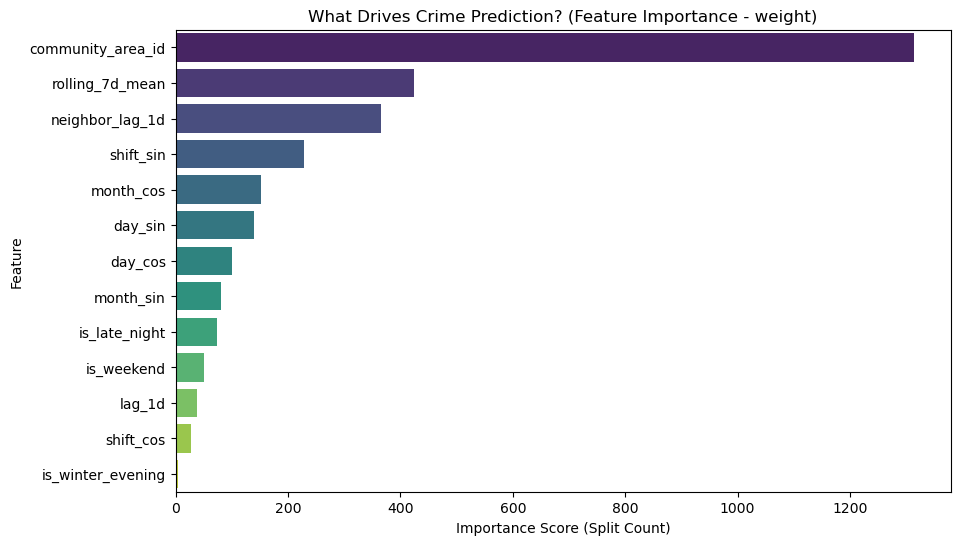

,Feature,Importance
1,community_area_id,1313.0
3,rolling_7d_mean,425.0
12,neighbor_lag_1d,366.0
10,shift_sin,228.0
7,month_cos,152.0
4,day_sin,140.0
5,day_cos,101.0
6,month_sin,81.0
8,is_late_night,73.0
0,is_weekend,51.0


In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract fitted XGBoost model and feature names from pipeline
if 'xgb_pipeline' not in globals():
    raise ValueError("xgb_pipeline not found. Run the model training cell first.")

if 'classifier' in xgb_pipeline.named_steps:
    xgb_model = xgb_pipeline.named_steps['classifier']
elif 'xgb' in xgb_pipeline.named_steps:
    xgb_model = xgb_pipeline.named_steps['xgb']
else:
    raise ValueError(f"Could not find XGBoost step in pipeline. Steps: {list(xgb_pipeline.named_steps.keys())}")

feature_names = list(X_train.columns)

# 2. Get importance scores from booster ('weight' = split count, instead of default gain)
raw_importances = xgb_model.get_booster().get_score(importance_type='weight')

# Map f0, f1, ... to real feature names and fill missing with 0
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': [raw_importances.get(f'f{i}', 0.0) for i in range(len(feature_names))]
}).sort_values(by='Importance', ascending=False)

# 3. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('What Drives Crime Prediction? (Feature Importance - weight)')
plt.xlabel('Importance Score (Split Count)')
plt.ylabel('Feature')
plt.show()

feat_imp_df

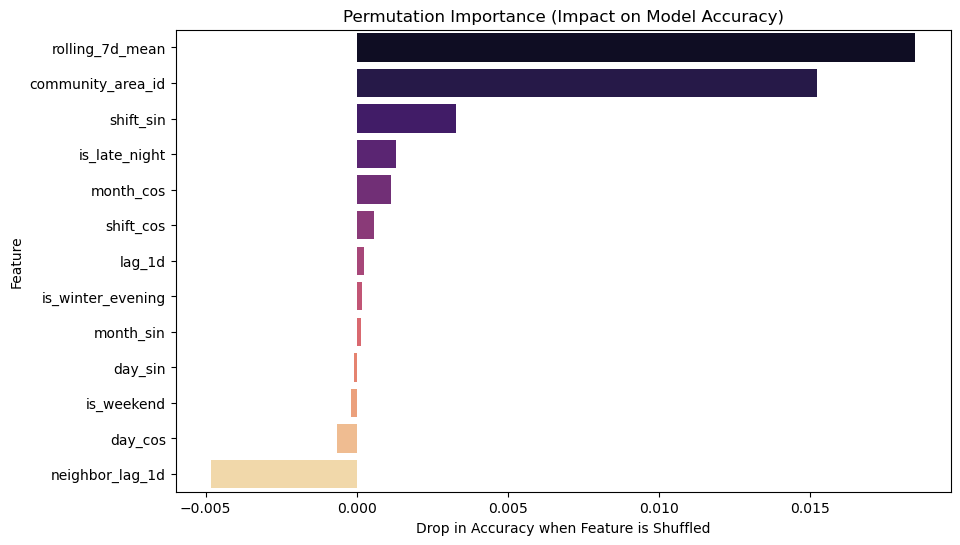

In [132]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Permutation Importance
# n_repeats=5 means it shuffles each column 5 times to get a stable average
result = permutation_importance(
    xgb_pipeline, X_test, y_test, 
    n_repeats=5, 
    random_state=42, 
    n_jobs=-1
)

# 2. Organize the results into a DataFrame
perm_imp_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance_Mean', y='Feature', data=perm_imp_df, palette='magma')
plt.title('Permutation Importance (Impact on Model Accuracy)')
plt.xlabel('Drop in Accuracy when Feature is Shuffled')
plt.show()

---
### Misc: Calibration of Best Model for Operational Deployment

Models are over confident. Threshold calibration ensures that the probability scores provided to patrol units are 'operationally honest,' allowing for more precise resource allocation and improved trust in the AI's recommendations.

XGBoost Brier Score      : 0.2076
Random Forest Brier Score: 0.2127
CatBoost Brier Score     : 0.2071
LightGBM Brier Score     : 0.2072


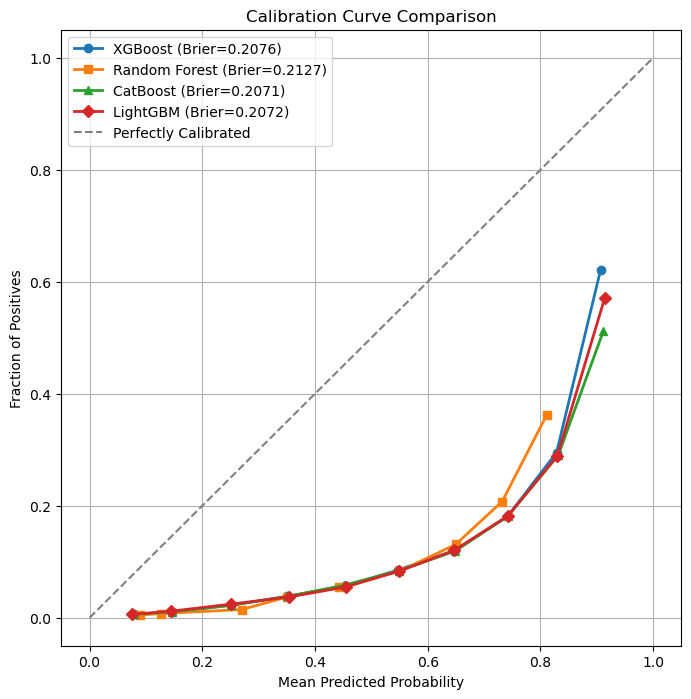

In [133]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Predicted probabilities
xgb_probs = xgb_pipeline.predict_proba(X_test)[:, 1]
rf_probs = rf_pipeline.predict_proba(X_test)[:, 1]
cat_probs = cat_pipeline.predict_proba(X_test)[:, 1]
lgb_probs = lgb_pipeline.predict_proba(X_test)[:, 1]

# Calibration curve points
xgb_true, xgb_pred = calibration_curve(y_test, xgb_probs, n_bins=10)
rf_true, rf_pred = calibration_curve(y_test, rf_probs, n_bins=10)
cat_true, cat_pred = calibration_curve(y_test, cat_probs, n_bins=10)
lgb_true, lgb_pred = calibration_curve(y_test, lgb_probs, n_bins=10)

# Brier scores (lower is better)
xgb_brier = brier_score_loss(y_test, xgb_probs)
rf_brier = brier_score_loss(y_test, rf_probs)
cat_brier = brier_score_loss(y_test, cat_probs)
lgb_brier = brier_score_loss(y_test, lgb_probs)

print(f"XGBoost Brier Score      : {xgb_brier:.4f}")
print(f"Random Forest Brier Score: {rf_brier:.4f}")
print(f"CatBoost Brier Score     : {cat_brier:.4f}")
print(f"LightGBM Brier Score     : {lgb_brier:.4f}")

# Plot reliability curves
plt.figure(figsize=(8, 8))
plt.plot(xgb_pred, xgb_true, marker='o', linewidth=2, label=f'XGBoost (Brier={xgb_brier:.4f})')
plt.plot(rf_pred, rf_true, marker='s', linewidth=2, label=f'Random Forest (Brier={rf_brier:.4f})')
plt.plot(cat_pred, cat_true, marker='^', linewidth=2, label=f'CatBoost (Brier={cat_brier:.4f})')
plt.plot(lgb_pred, lgb_true, marker='D', linewidth=2, label=f'LightGBM (Brier={lgb_brier:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()